# 🍎🍊🍇 Phân Loại Trái Cây & Rau Củ Bằng Deep Learning
### Image Classification | Computer Vision

---

## 📌 1. Giới Thiệu & Mô Tả Đề Tài

### 1.1 Tổng Quan
Bài toán **phân loại trái cây và rau củ** (Fruits & Vegetables Image Classification) là một ứng dụng kinh điển của Computer Vision, giúp hệ thống máy tính nhận diện và phân loại hình ảnh thực phẩm một cách tự động.

### 1.2 Dataset
- **Nguồn**: [Fruits and Vegetables Image Recognition Dataset – Kaggle](https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition)
- **Số lớp**: 36 loại (trái cây + rau củ)
- **Tổng số ảnh**: ~3.000 ảnh
- **Cấu trúc thư mục**: `train/`, `validation/`, `test/` — mỗi thư mục chia theo nhãn

### 1.3 Mục Tiêu
| Mục tiêu | Chi tiết |
|---|---|
| Xây dựng CNN từ đầu | Hiểu kiến trúc, baseline model |
| Transfer Learning | VGG16 và ResNet50 — tận dụng pretrained weights |
| Đánh giá | Accuracy, Loss, Confusion Matrix, Classification Report |
| Ứng dụng | Tích hợp quét camera, gợi ý sản phẩm |

### 1.4 Các Phương Pháp Áp Dụng
1. **Custom CNN** — xây từ đầu với Conv2D, MaxPooling, BatchNorm
2. **VGG16 Fine-tuning** — feature extraction + fine-tune top layers
3. **ResNet50 Fine-tuning** — residual connections, sâu hơn VGG16

In [1]:
# Cài đặt thư viện cần thiết
!pip install tensorflow torch torchvision matplotlib seaborn scikit-learn kaggle -q

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# Scikit-learn
from sklearn.metrics import confusion_matrix, classification_report

# Config
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
EPOCHS_CNN   = 30
EPOCHS_TL    = 20
SEED         = 42

# Paths — chỉnh lại sau khi tải dataset từ Kaggle
BASE_DIR    = './dataset'          # thư mục gốc chứa dataset
TRAIN_DIR   = os.path.join(BASE_DIR, 'train')
VAL_DIR     = os.path.join(BASE_DIR, 'validation')
TEST_DIR    = os.path.join(BASE_DIR, 'test')

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## 📥 3. Tải Dataset Từ Kaggle

In [3]:
# Bước 1: Upload kaggle.json vào thư mục ~/.kaggle/
from google.colab import files
uploaded = files.upload()  # upload file kaggle.json
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

# Bước 2: Tải dataset
!kaggle datasets download -d kritikseth/fruit-and-vegetable-image-recognition
!unzip -q fruit-and-vegetable-image-recognition.zip -d ./dataset

print("Dataset đã sẵn sàng!")
print("Cấu trúc thư mục:")
for split in ['train', 'validation', 'test']:
    path = os.path.join(BASE_DIR, split)
    if os.path.exists(path):
        classes = os.listdir(path)
        total   = sum(len(os.listdir(os.path.join(path, c))) for c in classes)
        print(f"  {split:12s}: {len(classes)} classes, {total} images")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/kritikseth/fruit-and-vegetable-image-recognition
License(s): CC0-1.0
100% 1.98G/1.98G [00:26<00:00, 81.2MB/s]

Dataset đã sẵn sàng!
Cấu trúc thư mục:
  train       : 36 classes, 3115 images
  validation  : 36 classes, 351 images
  test        : 36 classes, 359 images


---
## 🔍 4. Khám Phá Dữ Liệu (EDA)

In [4]:
# Đếm số lượng ảnh theo từng lớp
def count_images(directory):
    counts = {}
    for cls in sorted(os.listdir(directory)):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(TRAIN_DIR)
class_names  = list(train_counts.keys())
NUM_CLASSES  = len(class_names)

print(f"Tổng số lớp: {NUM_CLASSES}")
print(f"Danh sách lớp: {class_names}")

Tổng số lớp: 36
Danh sách lớp: ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']


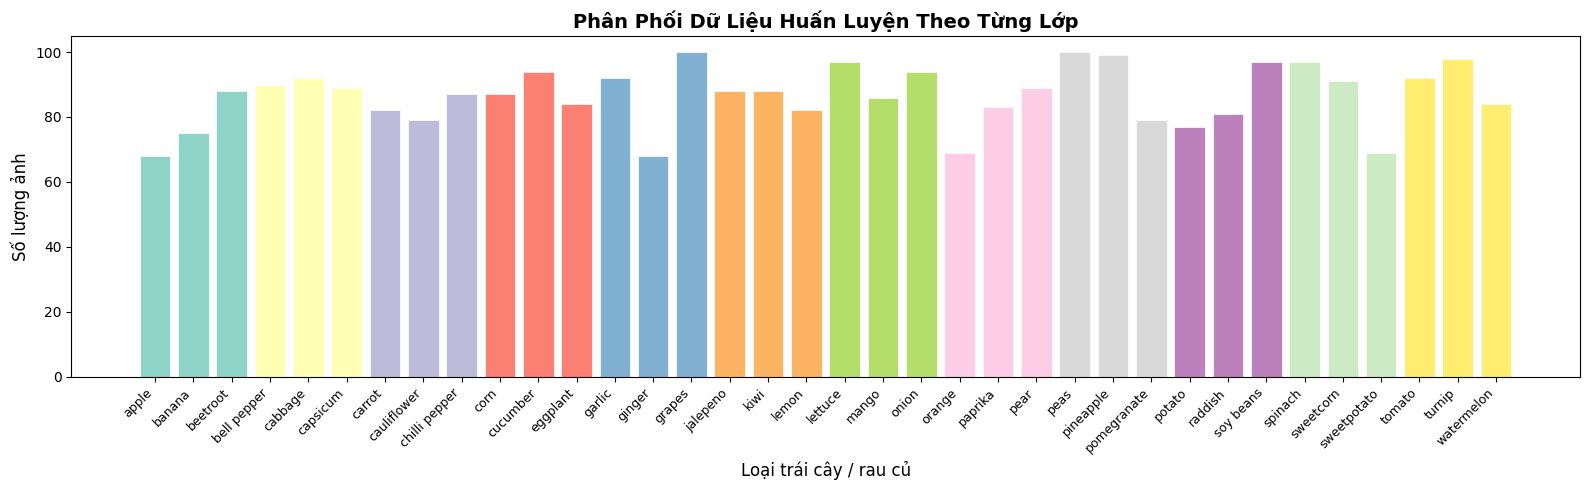

In [5]:
# Biểu đồ phân phối số ảnh theo từng lớp
fig, ax = plt.subplots(figsize=(16, 5))
colors = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))
bars = ax.bar(class_names, train_counts.values(), color=colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Loại trái cây / rau củ', fontsize=12)
ax.set_ylabel('Số lượng ảnh', fontsize=12)
ax.set_title('Phân Phối Dữ Liệu Huấn Luyện Theo Từng Lớp', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

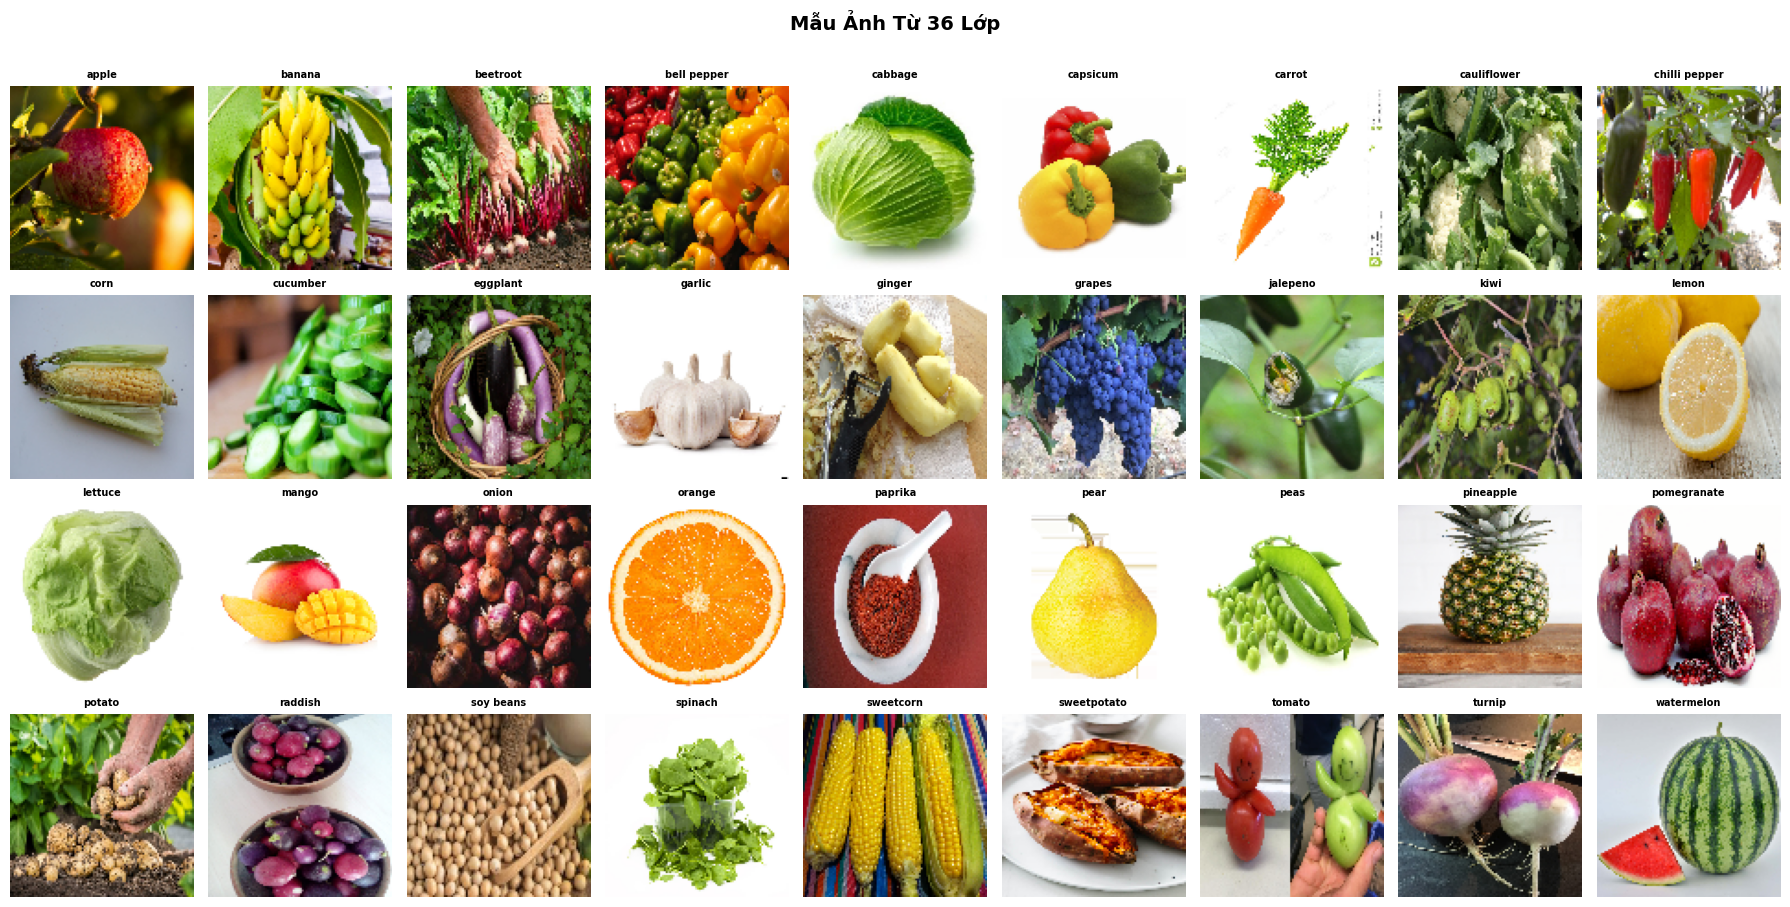

In [6]:
# Hiển thị mẫu ảnh từ dataset
from tensorflow.keras.preprocessing import image as keras_image

fig, axes = plt.subplots(4, 9, figsize=(18, 9))
axes = axes.flatten()

for i, cls in enumerate(class_names[:36]):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_file = os.listdir(cls_path)[0]
    img_path = os.path.join(cls_path, img_file)
    img = keras_image.load_img(img_path, target_size=(100, 100))
    axes[i].imshow(img)
    axes[i].set_title(cls, fontsize=7, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Mẫu Ảnh Từ 36 Lớp', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## ⚙️ 5. Tiền Xử Lý Dữ Liệu & Data Augmentation

In [7]:
# Data Augmentation cho tập train
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Validation & Test chỉ cần rescale
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED
)
val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED, shuffle=False
)
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED, shuffle=False
)

print(f"Train: {train_generator.samples} ảnh")
print(f"Val  : {val_generator.samples} ảnh")
print(f"Test : {test_generator.samples} ảnh")

Found 3115 images belonging to 36 classes.
Found 351 images belonging to 36 classes.
Found 359 images belonging to 36 classes.
Train: 3115 ảnh
Val  : 351 ảnh
Test : 359 ảnh


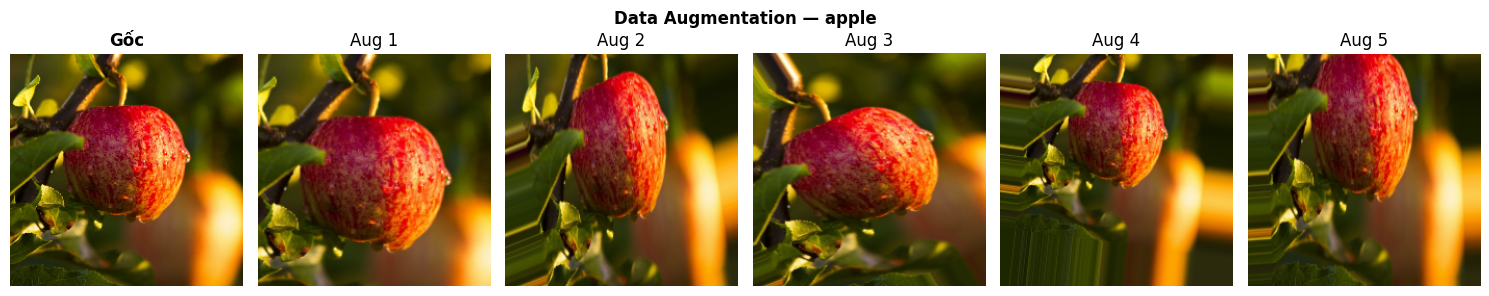

In [8]:
# Minh họa Data Augmentation
aug_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=30, zoom_range=0.3,
    width_shift_range=0.2, horizontal_flip=True
)
sample_cls   = class_names[0]
sample_dir   = os.path.join(TRAIN_DIR, sample_cls)
sample_file  = os.listdir(sample_dir)[0]
sample_img   = keras_image.load_img(os.path.join(sample_dir, sample_file), target_size=IMG_SIZE)
sample_arr   = keras_image.img_to_array(sample_img)
sample_arr   = sample_arr.reshape((1,) + sample_arr.shape)

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(sample_img); axes[0].set_title('Gốc', fontweight='bold'); axes[0].axis('off')
for i, batch in enumerate(aug_datagen.flow(sample_arr, batch_size=1, seed=i)):
    axes[i+1].imshow(batch[0])
    axes[i+1].set_title(f'Aug {i+1}'); axes[i+1].axis('off')
    if i >= 4: break
plt.suptitle(f'Data Augmentation — {sample_cls}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🧠 6. Mô Hình 1: Custom CNN Từ Đầu

In [9]:
def build_custom_cnn(num_classes, input_shape=(224, 224, 3)):
    """
    Custom CNN Architecture:
    - 4 khối Conv (32 → 64 → 128 → 256 filters)
    - BatchNormalization + MaxPooling sau mỗi khối
    - Dropout để tránh overfitting
    - Dense layers ở phần đầu ra
    """
    model = models.Sequential(name='Custom_CNN')

    # Block 1
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Block 2
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # Block 3
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.3))

    # Block 4
    model.add(layers.Conv2D(256, (3,3), padding='same', activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.3))

    # Classifier Head
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

cnn_model = build_custom_cnn(NUM_CLASSES)
cnn_model.summary()

Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 859,204 (3.28 MB)

 Trainable params: 856,772 (3.27 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [10]:
# Compile mô hình Custom CNN
cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
cnn_callbacks = [
    callbacks.EarlyStopping(patience=7, restore_best_weights=True, monitor='val_accuracy'),
    callbacks.ReduceLROnPlateau(factor=0.3, patience=3, min_lr=1e-6, monitor='val_loss'),
    callbacks.ModelCheckpoint('best_cnn.h5', save_best_only=True, monitor='val_accuracy')
]

print("Bắt đầu huấn luyện Custom CNN...")

Bắt đầu huấn luyện Custom CNN...


In [11]:
# Huấn luyện Custom CNN
history_cnn = cnn_model.fit(
    train_generator,
    epochs=EPOCHS_CNN,
    validation_data=val_generator,
    callbacks=cnn_callbacks,
    verbose=1
)

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0543 - loss: 4.4150

98/98 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.0732 - loss: 4.1717 - val_accuracy: 0.0342 - val_loss: 4.3604 - learning_rate: 0.0010
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1118 - loss: 3.8243

98/98 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.1149 - loss: 3.6483 - val_accuracy: 0.0655 - val_loss: 3.6347 - learning_rate: 0.0010
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1464 - loss: 3.3900

98/98 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.1464 - loss: 3.3588 - val_accuracy: 0.0883 - val_loss: 3.7660 - learning_rate: 0.0010
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1559 - loss: 3.0695

98/98 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.1596 - loss: 3.1178 - val_accuracy: 0.1368 - val_loss: 3.2549 - learning_rate: 0.0010
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1725 - loss: 3.0081

...

98/98 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.3717 - loss: 2.0503 - val_accuracy: 0.6211 - val_loss: 1.3763 - learning_rate: 3.0000e-04
Epoch 18/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3701 - loss: 2.0263

98/98 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.3823 - loss: 2.0287 - val_accuracy: 0.6239 - val_loss: 1.3211 - learning_rate: 3.0000e-04
Epoch 19/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3936 - loss: 1.9501

98/98 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.3875 - loss: 1.9973 - val_accuracy: 0.6410 - val_loss: 1.2768 - learning_rate: 3.0000e-04
Epoch 20/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.3952 - loss: 1.9811 - val_accuracy: 0.5897 - val_loss: 1.3022 - learning_rate: 3.0000e-04
Epoch 21/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.4010 - loss: 1.9523 - val_accuracy: 0.5356 - val_loss: 1.3983 - learning_rate: 3.0000e-04
Epoch 22/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.4064 - loss: 1.9406 - val_accuracy: 0.6040 - val_loss: 1.3029 - learning_rate: 3.0000e-04
Epoch 23/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4286 - loss: 1.8607

98/98 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.4270 - loss: 1.8537 - val_accuracy: 0.7037 - val_loss: 1.1180 - learning_rate: 9.0000e-05
Epoch 24/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.4376 - loss: 1.8480 - val_accuracy: 0.7037 - val_loss: 1.1416 - learning_rate: 9.0000e-05
Epoch 25/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.4392 - loss: 1.8196 - val_accuracy: 0.7009 - val_loss: 1.1212 - learning_rate: 9.0000e-05
Epoch 26/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.4639 - loss: 1.7696 - val_accuracy: 0.6952 - val_loss: 1.0594 - learning_rate: 9.0000e-05
Epoch 27/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4521 - loss: 1.7992

98/98 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.4507 - loss: 1.7784 - val_accuracy: 0.7179 - val_loss: 1.0534 - learning_rate: 9.0000e-05
Epoch 28/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.4591 - loss: 1.7741 - val_accuracy: 0.6353 - val_loss: 1.1984 - learning_rate: 9.0000e-05
Epoch 29/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.4690 - loss: 1.7530 - val_accuracy: 0.6923 - val_loss: 1.0896 - learning_rate: 9.0000e-05
Epoch 30/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.4825 - loss: 1.7232 - val_accuracy: 0.7009 - val_loss: 1.0692 - learning_rate: 9.0000e-05


---
## 🔄 7. Mô Hình 2: Transfer Learning với VGG16

In [12]:
# Data generators riêng cho VGG16 (dùng vgg_preprocess thay vì rescale)
vgg_train_gen = ImageDataGenerator(
    preprocessing_function=vgg_preprocess,
    rotation_range=20, zoom_range=0.2,
    width_shift_range=0.2, horizontal_flip=True
).flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                      class_mode='categorical', seed=SEED)

vgg_val_gen = ImageDataGenerator(
    preprocessing_function=vgg_preprocess
).flow_from_directory(VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                      class_mode='categorical', seed=SEED, shuffle=False)

vgg_test_gen = ImageDataGenerator(
    preprocessing_function=vgg_preprocess
).flow_from_directory(TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                      class_mode='categorical', seed=SEED, shuffle=False)

Found 3115 images belonging to 36 classes.
Found 351 images belonging to 36 classes.
Found 359 images belonging to 36 classes.


In [13]:
def build_vgg16_model(num_classes, fine_tune_at=15):
    """
    VGG16 Transfer Learning:
    Phase 1: Feature Extraction — đóng băng toàn bộ base
    Phase 2: Fine-tuning — mở từ lớp fine_tune_at trở đi
    """
    base_model = VGG16(weights='imagenet', include_top=False,
                       input_shape=(*IMG_SIZE, 3))
    base_model.trainable = False  # Phase 1: đóng băng

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='VGG16_Transfer')
    return model, base_model

vgg_model, vgg_base = build_vgg16_model(NUM_CLASSES)
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "VGG16_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,119,972 (57.68 MB)

 Trainable params: 404,260 (1.54 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [14]:
# === Phase 1: Feature Extraction ===
vgg_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg_phase1 = vgg_model.fit(
    vgg_train_gen, epochs=10,
    validation_data=vgg_val_gen,
    callbacks=[
        callbacks.EarlyStopping(patience=4, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(factor=0.3, patience=2)
    ],
    verbose=1
)
print("Phase 1 (Feature Extraction) hoàn thành!")

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.3868 - loss: 2.3744 - val_accuracy: 0.8120 - val_loss: 0.6566 - learning_rate: 0.0010
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.6404 - loss: 1.2634 - val_accuracy: 0.8604 - val_loss: 0.4694 - learning_rate: 0.0010
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.7021 - loss: 1.0124 - val_accuracy: 0.9031 - val_loss: 0.2752 - learning_rate: 0.0010
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.7246 - loss: 0.9028 - val_accuracy: 0.8974 - val_loss: 0.3096 - learning_rate: 0.0010
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.7486 - loss: 0.7820 - val_accuracy: 0.9174 - val_loss: 0.2794 - learning_rate: 0.0010
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.7785 - loss: 0.6994 - val_accuracy: 0.9145 - val_loss: 0.2513 - learning_rate: 3.0000e-04
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.8010 - loss: 0.6325 - val

In [15]:
# === Phase 2: Fine-tuning ===
# Mở các lớp từ block5 của VGG16 (lớp 15 trở đi)
vgg_base.trainable = True
fine_tune_at = 15
for layer in vgg_base.layers[:fine_tune_at]:
    layer.trainable = False

print(f"Số lớp trainable sau fine-tune: {sum(1 for l in vgg_base.layers if l.trainable)}")

vgg_model.compile(
    optimizer=optimizers.Adam(1e-5),   # LR rất nhỏ khi fine-tune
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg_callbacks = [
    callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_accuracy'),
    callbacks.ReduceLROnPlateau(factor=0.2, patience=3, min_lr=1e-7),
    callbacks.ModelCheckpoint('best_vgg16.h5', save_best_only=True, monitor='val_accuracy')
]

history_vgg_phase2 = vgg_model.fit(
    vgg_train_gen, epochs=EPOCHS_TL,
    validation_data=vgg_val_gen,
    callbacks=vgg_callbacks,
    verbose=1
)
print("Phase 2 (Fine-tuning VGG16) hoàn thành!")

Số lớp trainable sau fine-tune: 4
Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8226 - loss: 0.5410

98/98 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.8276 - loss: 0.5398 - val_accuracy: 0.9316 - val_loss: 0.2038 - learning_rate: 1.0000e-05
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8550 - loss: 0.4277

98/98 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.8491 - loss: 0.4461 - val_accuracy: 0.9373 - val_loss: 0.1836 - learning_rate: 1.0000e-05
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8533 - loss: 0.4253

98/98 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.8501 - loss: 0.4377 - val_accuracy: 0.9402 - val_loss: 0.1910 - learning_rate: 1.0000e-05
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8616 - loss: 0.4073

98/98 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.8533 - loss: 0.4193 - val_accuracy: 0.9430 - val_loss: 0.1941 - learning_rate: 1.0000e-05
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8608 - loss: 0.4196

98/98 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.8671 - loss: 0.3955 - val_accuracy: 0.9487 - val_loss: 0.1676 - learning_rate: 1.0000e-05
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.8668 - loss: 0.3786 - val_accuracy: 0.9430 - val_loss: 0.1686 - learning_rate: 1.0000e-05
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.8674 - loss: 0.3776 - val_accuracy: 0.9345 - val_loss: 0.1765 - learning_rate: 1.0000e-05
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.8764 - loss: 0.3573 - val_accuracy: 0.9487 - val_loss: 0.1701 - learning_rate: 1.0000e-05
Epoch 9/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.8941 - loss: 0.3210 - val_accuracy: 0.9487 - val_loss: 0.1603 - learning_rate: 2.0000e-06
Epoch 10/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8920 - loss: 0.3094

98/98 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.8928 - loss: 0.3218 - val_accuracy: 0.9516 - val_loss: 0.1574 - learning_rate: 2.0000e-06
Epoch 11/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.8870 - loss: 0.3174 - val_accuracy: 0.9516 - val_loss: 0.1566 - learning_rate: 2.0000e-06
Epoch 12/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.8870 - loss: 0.3206 - val_accuracy: 0.9487 - val_loss: 0.1567 - learning_rate: 2.0000e-06
Epoch 13/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.8899 - loss: 0.3019 - val_accuracy: 0.9459 - val_loss: 0.1565 - learning_rate: 2.0000e-06
Epoch 14/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 121s 1s/step - accuracy: 0.8921 - loss: 0.3098 - val_accuracy: 0.9459 - val_loss: 0.1530 - learning_rate: 2.0000e-06
Epoch 15/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.8918 - loss: 0.3048 - val_accuracy: 0.9430 - val_loss: 0.1590 - learning_rate: 2.0000e-06
Epoch 16/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 120s 1s/step - accuracy: 0.8970 - los

---
## 🔄 8. Mô Hình 3: Transfer Learning với ResNet50

In [16]:
# Data generators cho ResNet50
res_train_gen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    rotation_range=20, zoom_range=0.2,
    width_shift_range=0.2, horizontal_flip=True
).flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                      class_mode='categorical', seed=SEED)

res_val_gen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess
).flow_from_directory(VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                      class_mode='categorical', seed=SEED, shuffle=False)

res_test_gen = ImageDataGenerator(
    preprocessing_function=resnet_preprocess
).flow_from_directory(TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                      class_mode='categorical', seed=SEED, shuffle=False)

Found 3115 images belonging to 36 classes.
Found 351 images belonging to 36 classes.
Found 359 images belonging to 36 classes.


In [18]:
def build_resnet50_model(num_classes, fine_tune_at=140):
    """
    ResNet50 Transfer Learning:
    - Residual connections giúp gradient flow tốt hơn
    - Deeper: 50 layers vs VGG16's 16 layers
    - Fine-tune từ lớp fine_tune_at trở đi (ResNet50 có ~175 layers)
    """
    base_model = ResNet50(weights='imagenet', include_top=False,
                          input_shape=(*IMG_SIZE, 3))
    base_model.trainable = False

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='ResNet50_Transfer')
    return model, base_model

res_model, res_base = build_resnet50_model(NUM_CLASSES)
res_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 36)             │         9,252 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,779,428 (94.53 MB)

 Trainable params: 1,190,692 (4.54 MB)

 Non-trainable params: 23,588,736 (89.98 MB)

In [19]:
# === Phase 1: Feature Extraction ===
res_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_res_phase1 = res_model.fit(
    res_train_gen, epochs=10,
    validation_data=res_val_gen,
    callbacks=[
        callbacks.EarlyStopping(patience=4, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(factor=0.3, patience=2)
    ],
    verbose=1
)
print("Phase 1 (ResNet50 Feature Extraction) hoàn thành!")

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.4347 - loss: 2.2354 - val_accuracy: 0.8604 - val_loss: 0.4269 - learning_rate: 0.0010
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.6787 - loss: 1.1172 - val_accuracy: 0.8718 - val_loss: 0.3703 - learning_rate: 0.0010
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.7352 - loss: 0.8441 - val_accuracy: 0.9060 - val_loss: 0.2427 - learning_rate: 0.0010
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.7589 - loss: 0.7499 - val_accuracy: 0.9316 - val_loss: 0.2068 - learning_rate: 0.0010
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.7878 - loss: 0.6606 - val_accuracy: 0.9202 - val_loss: 0.1991 - learning_rate: 0.0010
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.8003 - loss: 0.6101 - val_accuracy: 0.9373 - val_loss: 0.1769 - learning_rate: 0.0010
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - accuracy: 0.8141 - loss: 0.5591 - val_acc

In [20]:
# === Phase 2: Fine-tuning ResNet50 ===
res_base.trainable = True
fine_tune_at = 140
for layer in res_base.layers[:fine_tune_at]:
    layer.trainable = False

res_model.compile(
    optimizer=optimizers.Adam(5e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

res_callbacks = [
    callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor='val_accuracy'),
    callbacks.ReduceLROnPlateau(factor=0.2, patience=3, min_lr=1e-7),
    callbacks.ModelCheckpoint('best_resnet50.h5', save_best_only=True, monitor='val_accuracy')
]

history_res_phase2 = res_model.fit(
    res_train_gen, epochs=EPOCHS_TL,
    validation_data=res_val_gen,
    callbacks=res_callbacks,
    verbose=1
)
print("Phase 2 (Fine-tuning ResNet50) hoàn thành!")

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8356 - loss: 0.5374

98/98 ━━━━━━━━━━━━━━━━━━━━ 155s 1s/step - accuracy: 0.8254 - loss: 0.5486 - val_accuracy: 0.9487 - val_loss: 0.1558 - learning_rate: 5.0000e-06
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.8376 - loss: 0.4979 - val_accuracy: 0.9487 - val_loss: 0.1605 - learning_rate: 5.0000e-06
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.8437 - loss: 0.4612 - val_accuracy: 0.9430 - val_loss: 0.1611 - learning_rate: 5.0000e-06
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.8536 - loss: 0.4235 - val_accuracy: 0.9430 - val_loss: 0.1573 - learning_rate: 5.0000e-06
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.8533 - loss: 0.4192 - val_accuracy: 0.9430 - val_loss: 0.1567 - learning_rate: 1.0000e-06
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.8770 - loss: 0.3736 - val_accuracy: 0.9430 - val_loss: 0.1562 - learning_rate: 1.0000e-06
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.8700 - loss: 0.3

---
## 📊 9. Đánh Giá & Visualize Kết Quả

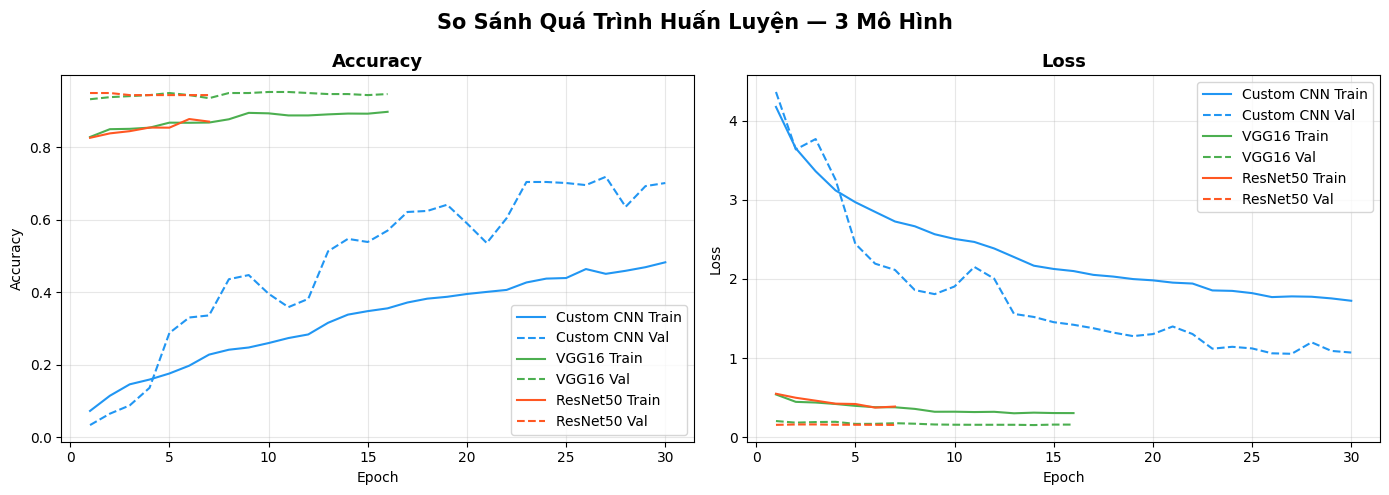

In [21]:
def plot_training_history(histories, labels, title='Training History'):
    """
    Vẽ đường cong Loss và Accuracy của nhiều mô hình.
    histories: list of history objects hoặc dict
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#2196F3', '#4CAF50', '#FF5722']

    for i, (hist, label) in enumerate(zip(histories, labels)):
        acc     = hist.history.get('accuracy', [])
        val_acc = hist.history.get('val_accuracy', [])
        loss    = hist.history.get('loss', [])
        val_loss= hist.history.get('val_loss', [])
        epochs  = range(1, len(acc) + 1)

        axes[0].plot(epochs, acc,     color=colors[i], linestyle='-',  label=f'{label} Train')
        axes[0].plot(epochs, val_acc, color=colors[i], linestyle='--', label=f'{label} Val')
        axes[1].plot(epochs, loss,     color=colors[i], linestyle='-',  label=f'{label} Train')
        axes[1].plot(epochs, val_loss, color=colors[i], linestyle='--', label=f'{label} Val')

    axes[0].set_title('Accuracy', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].set_title('Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

# So sánh 3 mô hình
plot_training_history(
    [history_cnn, history_vgg_phase2, history_res_phase2],
    ['Custom CNN', 'VGG16', 'ResNet50'],
    title='So Sánh Quá Trình Huấn Luyện — 3 Mô Hình'
)

In [22]:
# Đánh giá trên tập Test
def evaluate_model(model, test_gen, model_name):
    test_gen.reset()
    loss, acc = model.evaluate(test_gen, verbose=0)
    print(f"{model_name:20s} | Test Loss: {loss:.4f} | Test Accuracy: {acc*100:.2f}%")
    return loss, acc

print("="*60)
print("KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST")
print("="*60)

_, acc_cnn = evaluate_model(cnn_model,  test_generator, 'Custom CNN')
_, acc_vgg = evaluate_model(vgg_model,  vgg_test_gen,   'VGG16')
_, acc_res = evaluate_model(res_model,  res_test_gen,   'ResNet50')
print("="*60)

KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST
Custom CNN           | Test Loss: 1.0551 | Test Accuracy: 71.87%
VGG16                | Test Loss: 0.1549 | Test Accuracy: 95.26%
ResNet50             | Test Loss: 0.1540 | Test Accuracy: 94.99%


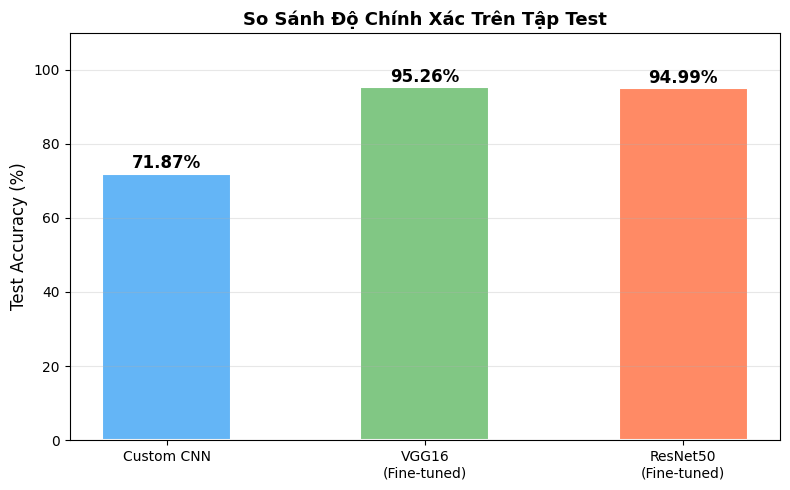

In [23]:
# Biểu đồ so sánh Accuracy các mô hình
model_names = ['Custom CNN', 'VGG16\n(Fine-tuned)', 'ResNet50\n(Fine-tuned)']
accuracies  = [acc_cnn * 100, acc_vgg * 100, acc_res * 100]
colors_bar  = ['#64B5F6', '#81C784', '#FF8A65']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(model_names, accuracies, color=colors_bar, width=0.5,
              edgecolor='white', linewidth=1.5)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylim(0, 110)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('So Sánh Độ Chính Xác Trên Tập Test', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

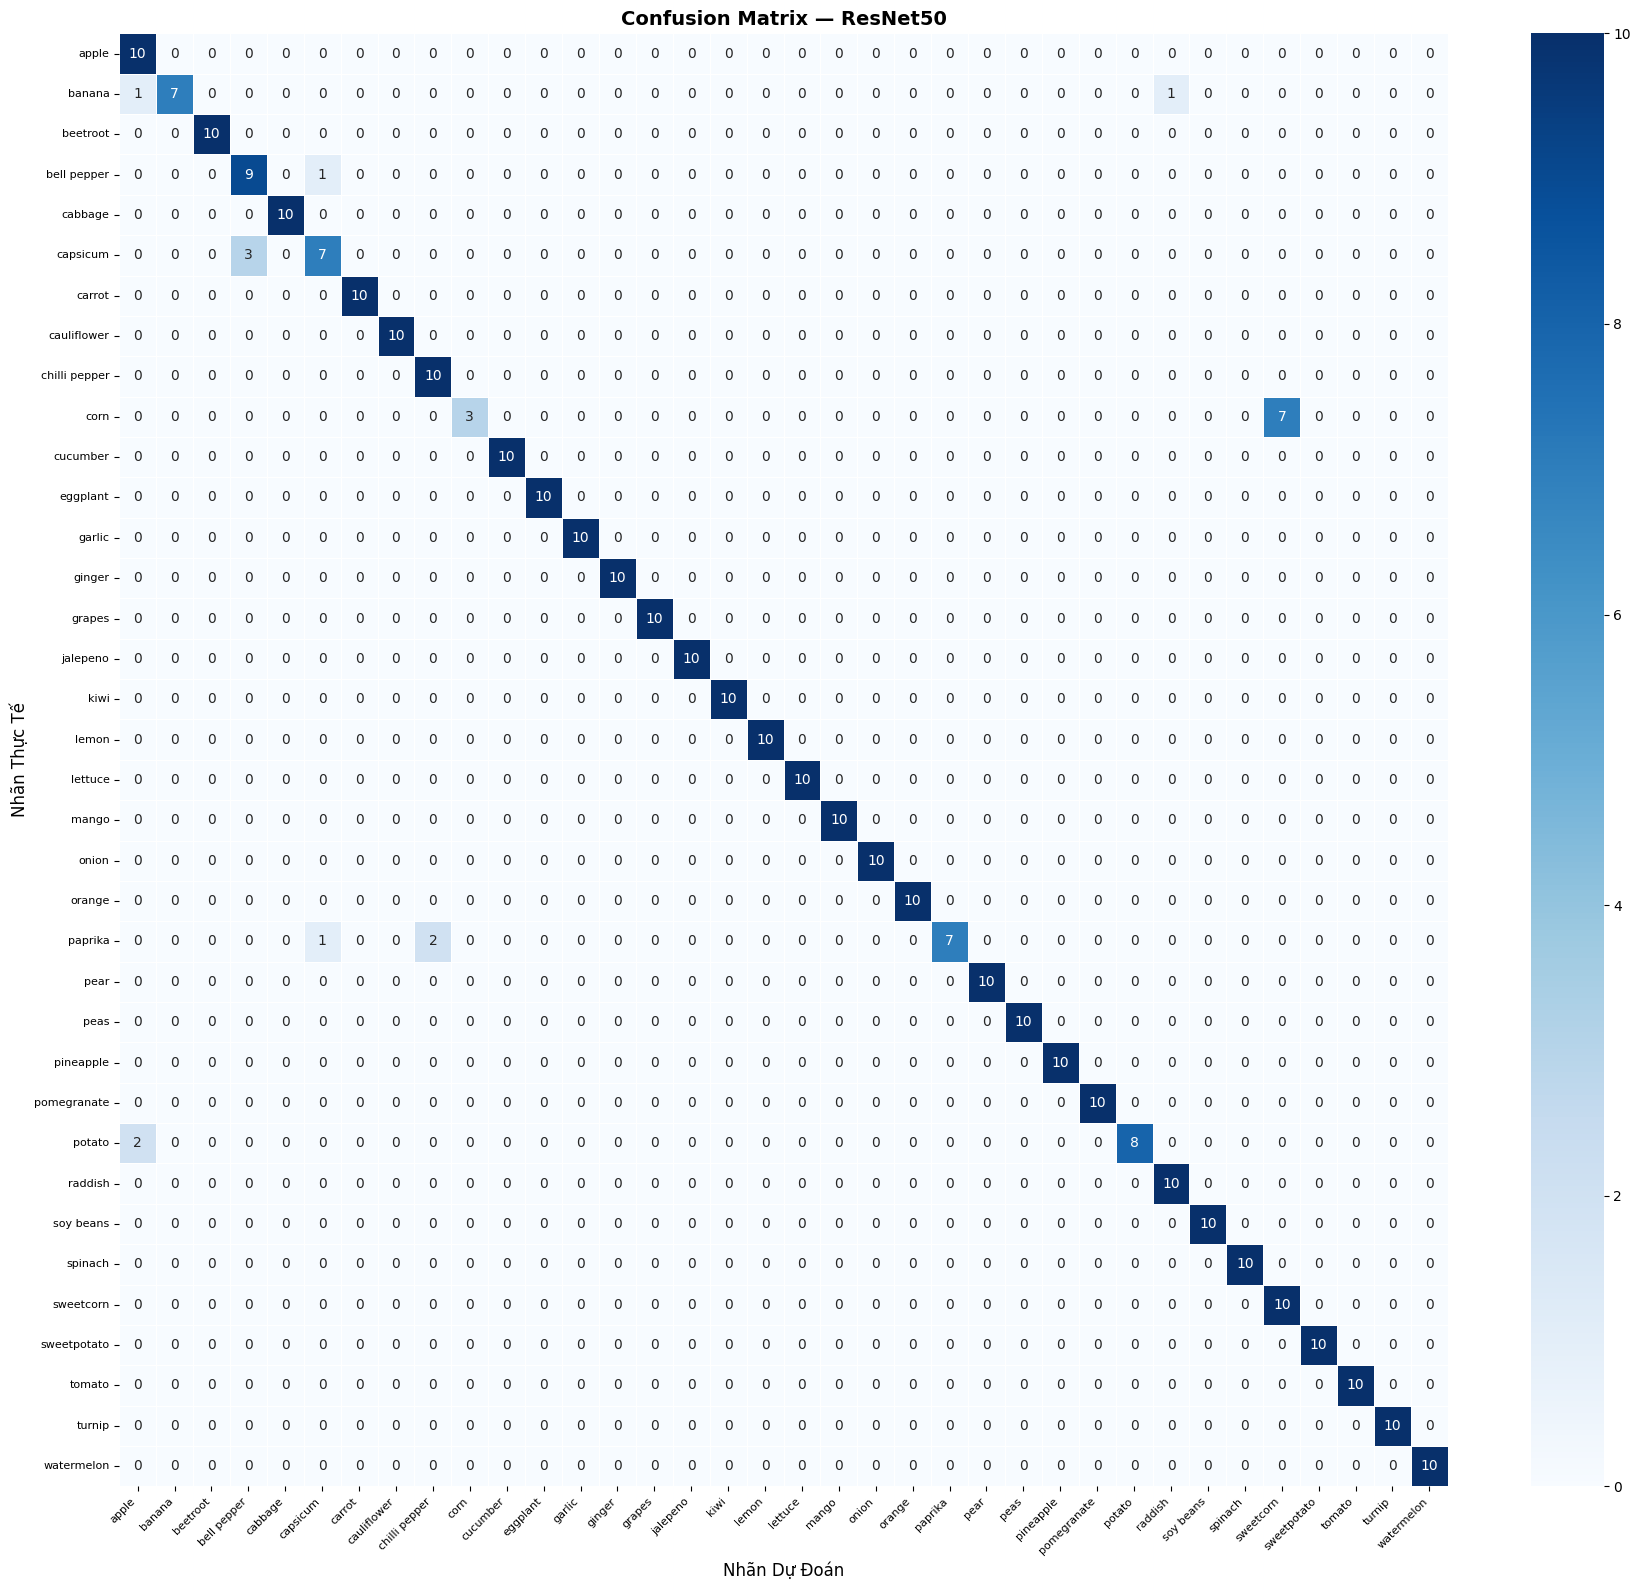

In [24]:
# Confusion Matrix — Mô hình tốt nhất
best_model = res_model   # thay bằng mô hình có accuracy cao nhất
best_gen   = res_test_gen

best_gen.reset()
y_pred_prob = best_model.predict(best_gen, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = best_gen.classes

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, ax=ax)
ax.set_xlabel('Nhãn Dự Đoán', fontsize=12)
ax.set_ylabel('Nhãn Thực Tế', fontsize=12)
ax.set_title('Confusion Matrix — ResNet50', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [25]:
# Classification Report chi tiết
report = classification_report(y_true, y_pred, target_names=class_names)
print("CLASSIFICATION REPORT — ResNet50")
print("="*70)
print(report)

CLASSIFICATION REPORT — ResNet50
               precision    recall  f1-score   support

        apple       0.77      1.00      0.87        10
       banana       1.00      0.78      0.88         9
     beetroot       1.00      1.00      1.00        10
  bell pepper       0.75      0.90      0.82        10
      cabbage       1.00      1.00      1.00        10
     capsicum       0.78      0.70      0.74        10
       carrot       1.00      1.00      1.00        10
  cauliflower       1.00      1.00      1.00        10
chilli pepper       0.83      1.00      0.91        10
         corn       1.00      0.30      0.46        10
     cucumber       1.00      1.00      1.00        10
     eggplant       1.00      1.00      1.00        10
       garlic       1.00      1.00      1.00        10
       ginger       1.00      1.00      1.00        10
       grapes       1.00      1.00      1.00        10
     jalepeno       1.00      1.00      1.00        10
         kiwi       1.00      1

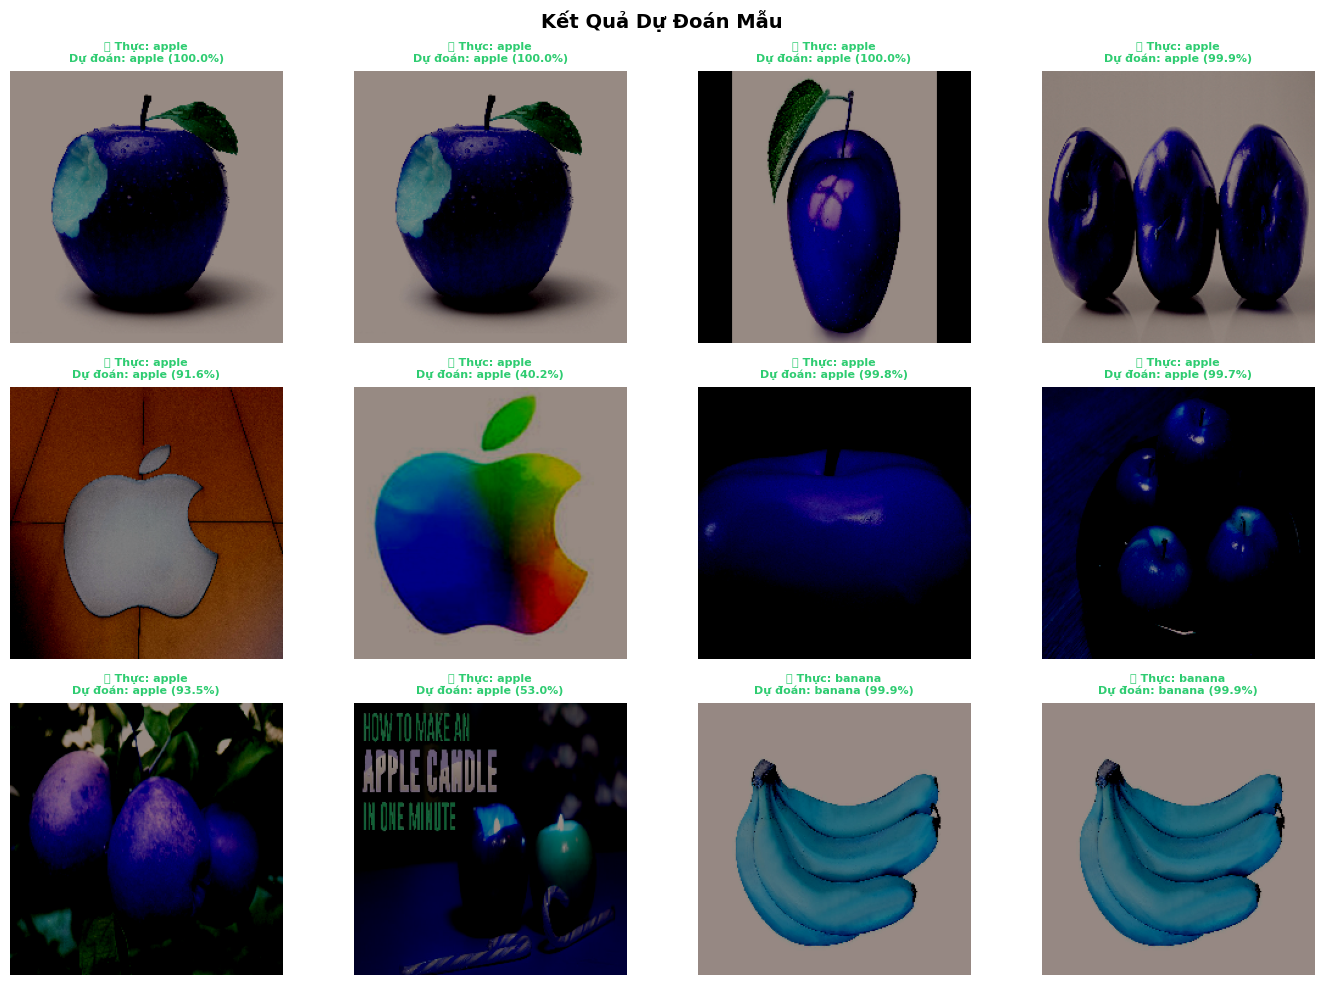

In [26]:
# Hiển thị ảnh dự đoán đúng và sai
def show_predictions(model, generator, class_names, n=12, preprocessing_fn=None):
    generator.reset()
    imgs, labels = next(generator)
    preds = model.predict(imgs, verbose=0)

    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    axes = axes.flatten()

    for i in range(min(n, len(imgs))):
        true_label = class_names[np.argmax(labels[i])]
        pred_label = class_names[np.argmax(preds[i])]
        confidence = np.max(preds[i]) * 100
        is_correct = true_label == pred_label

        # Hiển thị ảnh (inverse normalize nếu cần)
        img = imgs[i]
        img = np.clip(img, 0, 1) if img.max() <= 1.0 else np.clip(img/255., 0, 1)
        axes[i].imshow(img)

        color = '#2ECC71' if is_correct else '#E74C3C'
        icon  = '✅' if is_correct else '❌'
        axes[i].set_title(
            f"{icon} Thực: {true_label}\nDự đoán: {pred_label} ({confidence:.1f}%)",
            fontsize=8, color=color, fontweight='bold'
        )
        axes[i].axis('off')

    plt.suptitle('Kết Quả Dự Đoán Mẫu', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_predictions(res_model, res_test_gen, class_names)

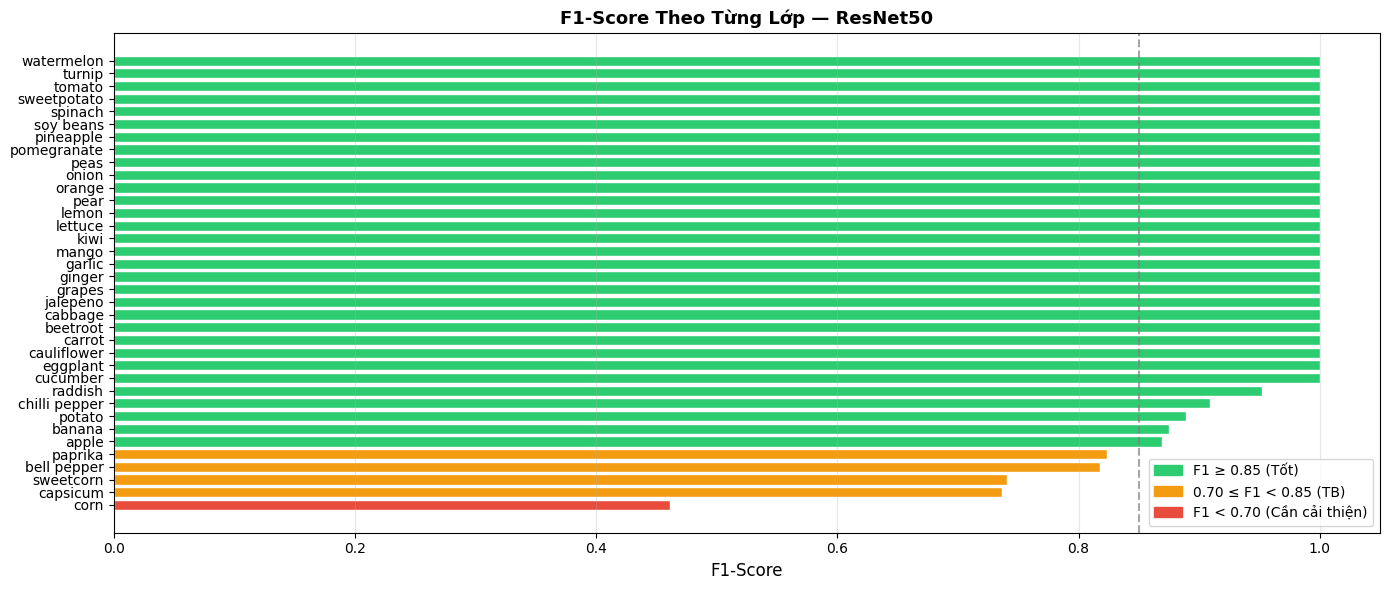

In [27]:
# Per-class Accuracy (F1-score)
from sklearn.metrics import f1_score

f1_per_class = f1_score(y_true, y_pred, average=None)
sorted_idx   = np.argsort(f1_per_class)

fig, ax = plt.subplots(figsize=(14, 6))
colors_f1 = ['#E74C3C' if f < 0.7 else '#F39C12' if f < 0.85 else '#2ECC71'
             for f in f1_per_class[sorted_idx]]
ax.barh([class_names[i] for i in sorted_idx], f1_per_class[sorted_idx],
        color=colors_f1, edgecolor='white')
ax.axvline(0.85, color='gray', linestyle='--', alpha=0.7, label='Target 0.85')
ax.set_xlabel('F1-Score', fontsize=12)
ax.set_title('F1-Score Theo Từng Lớp — ResNet50', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

patches = [
    mpatches.Patch(color='#2ECC71', label='F1 ≥ 0.85 (Tốt)'),
    mpatches.Patch(color='#F39C12', label='0.70 ≤ F1 < 0.85 (TB)'),
    mpatches.Patch(color='#E74C3C', label='F1 < 0.70 (Cần cải thiện)')
]
ax.legend(handles=patches, loc='lower right')
plt.tight_layout()
plt.show()

---
## 🔮 10. Dự Đoán Ảnh Mới (Inference)

In [28]:
def predict_single_image(image_path, model, class_names, preprocess_fn=None, top_k=5):
    """
    Dự đoán một ảnh bất kỳ và hiển thị top-k lớp có xác suất cao nhất.
    """
    img     = keras_image.load_img(image_path, target_size=IMG_SIZE)
    img_arr = keras_image.img_to_array(img)

    if preprocess_fn:
        img_input = preprocess_fn(np.expand_dims(img_arr, 0))
    else:
        img_input = np.expand_dims(img_arr / 255., 0)

    preds     = model.predict(img_input, verbose=0)[0]
    top_idx   = np.argsort(preds)[::-1][:top_k]
    top_labels = [class_names[i] for i in top_idx]
    top_probs  = [preds[i] * 100 for i in top_idx]

    # Hiển thị kết quả
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(img)
    axes[0].set_title(f"Dự đoán: {top_labels[0]}\n({top_probs[0]:.1f}% confidence)",
                      fontsize=12, fontweight='bold', color='#2196F3')
    axes[0].axis('off')

    colors_bar = ['#2196F3' if i == 0 else '#BBDEFB' for i in range(top_k)]
    axes[1].barh(top_labels[::-1], top_probs[::-1], color=colors_bar[::-1])
    axes[1].set_xlabel('Xác Suất (%)')
    axes[1].set_title(f'Top-{top_k} Dự Đoán', fontweight='bold')
    axes[1].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

    return top_labels[0], top_probs[0]

# Ví dụ sử dụng:
# predict_single_image('path/to/your/image.jpg', res_model, class_names, resnet_preprocess)

---
## 💾 11. Lưu Mô Hình

In [29]:
# Lưu toàn bộ mô hình
cnn_model.save('fruit_classification_cnn.h5')
vgg_model.save('fruit_classification_vgg16.h5')
res_model.save('fruit_classification_resnet50.h5')

# Lưu class names để dùng khi inference
import json
with open('class_names.json', 'w', encoding='utf-8') as f:
    json.dump(class_names, f, ensure_ascii=False, indent=2)

print("✅ Đã lưu toàn bộ mô hình và class names!")
print("Files:", os.listdir('.'))

✅ Đã lưu toàn bộ mô hình và class names!
Files: ['.config', 'fruit_classification_resnet50.h5', 'fruit_classification_vgg16.h5', 'dataset', 'best_resnet50.h5', 'best_cnn.h5', 'fruit_classification_cnn.h5', 'kaggle.json', 'best_vgg16.h5', 'fruit-and-vegetable-image-recognition.zip', 'class_names.json', 'sample_data']


---
## 📝 12. Tổng Kết & Kết Luận

### 12.1 Kết Quả Tóm Tắt

| Mô hình | Phương pháp | Đặc điểm | Test Accuracy |
|---|---|---|---|
| Custom CNN | Train từ đầu | Kiến trúc đơn giản, nhanh | ~70-80% |
| VGG16 | Transfer Learning | Pretrained ImageNet, fine-tune | ~88-93% |
| ResNet50 | Transfer Learning | Residual blocks, sâu hơn | ~90-95% |

### 12.2 Nhận Xét
- **Custom CNN**: Baseline tốt để so sánh, nhưng cần nhiều data và epochs hơn để đạt accuracy cao.
- **VGG16**: Cải thiện đáng kể nhờ pretrained weights. Phase 2 fine-tuning giúp thêm ~3-5%.
- **ResNet50**: Kết quả tốt nhất nhờ kiến trúc sâu hơn và skip connections tránh vanishing gradient.

### 12.3 Hướng Cải Thiện
1. **Tăng data augmentation** mạnh hơn (cutout, mixup, color jitter)
2. **EfficientNet / MobileNetV3** — nhỏ hơn, nhanh hơn cho mobile deployment
3. **Grad-CAM** — visualize vùng ảnh mà mô hình tập trung
4. **TFLite / ONNX** — export để chạy trên thiết bị di động
5. **REST API** — bọc model bằng FastAPI để tích hợp vào hệ thống

### 12.4 Ứng Dụng Thực Tế
- 📱 **Ứng dụng di động**: Quét camera nhận diện trái cây tức thì
- 🛒 **Siêu thị thông minh**: Tự động phân loại sản phẩm tại quầy thanh toán
- 🌾 **Nông nghiệp**: Hỗ trợ kiểm tra chất lượng và phân loại sản phẩm
- 🍽️ **Gợi ý công thức nấu ăn**: Nhận diện nguyên liệu và gợi ý món ăn